# Coursework Set week 4

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: L.B.J.SUBERBERE
* Username: lbjsuberbere
* Student number: s6080081
* Group (AS1, etc.): AS2

-----

In [1]:
totalpoints = currentpoints = 0

### Monte Carlo Error Propagation (4 pt) <font color='red'><b>COURSEWORK</b></font>

One of the classical Physic Lab experiment is to use pendulum to calculate the local gravitational acceleration, ``g``, from the measurements of the pendulum length ``L`` and the oscillation period ``T``.

The formula is expressed as follows:

$$ g=\frac{4\pi^2 L}{T^2} $$

You have got a set of measurements of $L=1.00\pm0.01\ \mathrm{(m)}$ and $T=2.01\pm0.02\ \mathrm{(s)}$.

* Like in Physics Lab, use Tyler expansion described above to propagate the error. Write your derivation in Markdown.

* Calculate the error of the derived ``g``.

* Apply Monte Carlo error propagation to estimate the value and uncertainty of ``g``.

* Make appropriate comments.

* Compare the two results.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Given Measurements
L = 1.00      # m
sigma_L = 0.01 
T = 2.01      # s
sigma_T = 0.02

#Taylor Expansion
g_val = (4 * np.pi**2 * L) / (T**2)
dg_dL = (4 * np.pi**2) / (T**2)
dg_dT = -(8 * np.pi**2 * L) / (T**3)
sigma_g_taylor = np.sqrt((dg_dL * sigma_L)**2 + (dg_dT * sigma_T)**2)

#Monte Carlo Simulation
N = 100000  # Number of samples
L_samples = np.random.normal(L, sigma_L, N)
T_samples = np.random.normal(T, sigma_T, N)
g_samples = (4 * np.pi**2 * L_samples) / (T_samples**2)
g_mc_mean = np.mean(g_samples)
sigma_g_mc = np.std(g_samples)

print(f"Taylor Expansion Results : {g_val:.4f} +/- {sigma_g_taylor:.4f} m/s^2")
print(f"Monte Carlo Results : {g_mc_mean:.4f} +/- {sigma_g_mc:.4f} m/s^2")
print(f"The two results match an are in equivalent range")

Taylor Expansion Results : 9.7716 +/- 0.2176 m/s^2
Monte Carlo Results : 9.7754 +/- 0.2177 m/s^2
The two results match an are in equivalent range


<div class='alert alert-warning'>
    <b>Feedback</b> <br>
Missing error propagation derivation in markdown. Make sure to include this in your correction. <b>[1pt deducted from total grade.]</b>
</div>

Error Propagation using Taylor Expansion

We are given the formula:
$g = \frac{4\pi^2 L}{T^2}$

To propagate the uncertainty from $L$ and $T$ to $g$, we use the first-order Taylor expansion for independent variables:
$\sigma_g^2 = \left(\frac{\partial g}{\partial L}\right)^2 \sigma_L^2 + \left(\frac{\partial g}{\partial T}\right)^2 \sigma_T^2$

$\frac{\partial g}{\partial L} = \frac{4\pi^2}{T^2}$

$\frac{\partial g}{\partial T} = -\frac{8\pi^2 L}{T^3}$

$\sigma_g^2 =\left( \frac{4\pi^2}{T^2} \right)^2 \sigma_L^2+\left( \frac{8\pi^2 L}{T^3} \right)^2 \sigma_T^2$

$\sigma_g =\sqrt{\left( \frac{4\pi^2}{T^2} \sigma_L \right)^2+\left( \frac{8\pi^2 L}{T^3} \sigma_T \right)^2}$

In [3]:
# Leave unaltered
totalpoints += 4
currentpoints += 3

### Complex roots of a quadratic equation (4 pt) <font color='red'><b>COURSEWORK</b></font>
  
Use the information in the notebook about complex numbers to write a program that can calculate the (complex) roots of a quadratic equation with the quadratic formula:

$$ y=ax^2+bx+c $$

The requirement of this program is as follows:

* User can supply constants ``a``, ``b`` and ``c`` with Python function `input()`.
* The program can deal with complex roots.
* Your program must print the equation with its constants and its roots.
* The solutions must be inserted to the original equation to prove that $f(x)=0$.

**Answer**:

In [ ]:
from math import *
import numpy as np

#Determination of the values for a, b and c in the function
a = float(input("The value of a is "))
b = float(input("The value of b is "))
c = float(input("The value of c is "))

#Calculation of the discrimiant
D = b**2 -4*a*c

#Calculation of the roots given the value for the discriminant; two real if it is superior to zero, one real if it equals zero, two complex cojugaute if it is inferior to zero
print(f'The function y = {a}x^2 + {b}x + {c} has ', end = '' )
if D > 0 : 
    x_1 = (-b + sqrt(D)) / (2*a)
    x_2 = (-b - sqrt(D)) / (2*a)
    print (f"two real roots {x_1} and {x_2}")
    p1 = (a*(x_1**2)) + (b*x_1) + c
    p2 = (a*(x_2**2)) + (b*x_2) + c
    print(f'The result of trying the root gives {p1} for {x_1} and {p2} for {x_2}')
elif D == 0 :
    x0 = -b/2*a
    print (f"one unique root {x0}")
    p = (a*(x0**2)) + (b*x0) + c
    print(f'The result of trying the root gives {p}')
elif D < 0 : 
    x1 = complex((-b/2*a) , sqrt(abs(D))/(2*a))
    x2 = np.conjugate(x1)
    print(f'has two complex conjugate roots {x1} and {x2}')
    p1 = (a*(x1**2)) + (b*x1) + c
    p2 = (a*(x2**2)) + (b*x2) + c
    print(f'The result of trying the root gives {p1} for {x1} and {p2} for {x2}')

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 4

### Area under a Gaussian (6 pt) <font color='red'><b>COURSEWORK</b></font>

A one dimensional Gaussian function is given by:

$$f(x) = A\ e^{\frac{-{(x-x_0)}^2}{2 \sigma^2}} + z_0$$

$A$ is the amplitude, $x_0$ is the position of the peak, $\sigma$ is the width of the peak
and $z_0$ is the offset in $y$.  

This function can be written in Python as follows:

```python
def gauss(x, A, x0, sigma, z0):
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0
```

1. Set in the calling environment:
```python
    A = 1.0
    x0 = 0.0
    sig = 2.0
    z0 = 0.0
```
2. Plot this function between -10 and 10 with 200 samples.
3. Use function `scipy.integrate.quad()` to find the area between ``x=0`` and ``x=2.5``.
4. Use function `matplotlib.pyplot.fill_between()` to mark that area in your plot.
5. Calculate the area between $-\infty$ and $\infty$ ($\approx 5.01$).
6. Given is the integral for the total area under the curve:

    $$\int _{-\infty }^{\infty }Ae^{-(x-x_0)^{2}/(2\sigma^{2})}\,\mathrm{d}x=A \sigma \cdot {\sqrt {2\pi }}$$

   Calculate this area for the values of the parameters given above and prove with ``quad()`` that the two are the same.

7. Make the last part an executable script, called ``gaussarea``. The user can enter values for ``A``, ``x0``, ``sig`` and ``z0`` and the integration limits. The programme then calculates the area under the curve between the integration limits using function ``quad()``. The programme must includes a plot of the curve, the integration area, and the value of that area in a legend.
8. Insert the generated plot in a separate markdown cell below your code cell, and upload your script to GitHub. Provide your GitHub website link in the notebook too for TA to check. 
   
**Answers**:   

In [ ]:
from math import *
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.constants

fig, (ax1, ax2) = plt.subplots(2)

def gauss(x, A, x0, sigma, z0):
    """Gaussian Function"""
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

#Plotting the gauss function from a value of x from -20 to 20
A = 1.0
x0 = 0.0
sig = 2.0
z0 = 0.0
x = np.linspace(-20, 20, 200)
ax1.plot(x, gauss(x, A, x0, sig, z0), color = 'red', label = 'Coursework gaussian function')
fig.suptitle('Gaussian Functions')
fig.supxlabel('X')
fig.supylabel('Y')

#Calculation of the integral using the quad method
Area = scipy.integrate.quad(gauss, 0, 2.5, args=(A, x0, sig, z0))
print(f'The value of the area using the quad method is {Area}')
ax1.fill_between(np.linspace(0, 2.5, 200), gauss(np.linspace(0, 2.5, 200), A, x0, sig, z0), color = 'pink', label = 'Area value is about {}'.format((Area[0])))
Areainf = scipy.integrate.quad(gauss, -np.inf, np.inf, args=(A, x0, sig, z0))
print(Areainf)

Calc1 = A*sig*sqrt(2*pi)
print(f'The calculated from the equation {Calc1} is equal to that calculated with quad {Areainf[0]}')


A = float(input('The value of A is '))
x0 = float(input('The value of x0 is '))
sig = float(input('The value of sog is '))
z0 = float(input('The value of z0 is '))
limmin = float(input('The value of min lim is '))
limmax = float(input('The value of max lim is '))

def gaussarea(x, A, x0, sigma, z0):
    """Gaussian Function"""
    return A*np.exp(-(x-x0)**2/(2*sigma**2))+z0

x = np.linspace(limmin, limmax, 200)
ax2.plot(np.linspace(-20, 20, 200), gauss(np.linspace(-20, 20, 200), A, x0, sig, z0), color = 'orange', label = 'User gaussian function')
#Calculation of the integral using the quad method
Area2 = scipy.integrate.quad(gaussarea, limmin, limmax, args=(A, x0, sig, z0))
print(f'The value of the area using the quad method is {Area2}')
ax2.fill_between(np.linspace(limmin, limmax, 200), gauss(np.linspace(limmin, limmax, 200), A, x0, sig, z0), color = 'purple', label = 'Area value is about {}'.format((Area2[0])))
fig.legend()

The generated plots appear when the previous code is played, the second looks like the picture here when the variables have identical values as initial given but I invite you to check by running the code
You can find the GitHub file on this link (the code is Area under a gaussiannGitHub script) 
https://github.com/louis8958/PROGNUM-repo/tree/e8911c0cae5c3fdd1682babaf16718ab77431bca/Task4
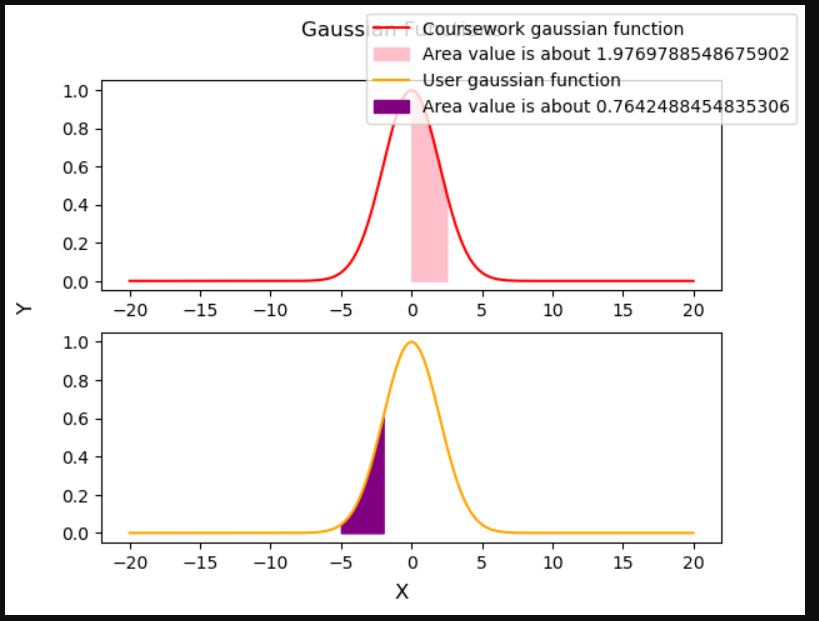

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

You provided your GitHub, but I can't find a executable script called `gaussarea` in your repo. An executable means a `.py` file, and not your notebook. <b>[1pt deducted from total grade.]</b>

Your script where the user can input values does not plot correctly. The plot only shows the selected area. But you are meant to show a full bell curve and only mark the area you want to integrate over (like the plot before). <b>[0.5pt deducted from total grade.]</b>
</div>

I have added the script in my github, the link is here https://github.com/louis8958/PROGNUM-repo/tree/a1368e59ef50e52520342dc412940df14ae25aa9/Task4 it is called gaussarea. I also have modified the code so that the limit now correspond to the area only and not to what is shown of the gaussian function, this one has now permanant limits of -20 to 20. I also have changed the previous screenshot.

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 4.5

### Calculate integral of a user supplied function (6 pt) <font color='red'><b>COURSEWORK</b></font>

Write a programme that calculates the integral of any function from the user input using ``eval()``, which is a string representing a function and a variable (floating number) for which the function will be evaluated.

* Call from ``numpy import sin, cos, exp, pi`` to apply these functions and constants in your code.
* Use ``scipy.integrate.quad()`` to calculate the integral of the formula below between $x=0$ and $x=\pi$
* Use Monte Carlo Integration to calculate the integral of the formula below for $x=0$ and $x=\pi$

$$ f(x)=x^4+e^{\sin{x}+\cos{x}} $$

Make the function robust with try/except clauses. Demonstrate exceptions for wrong expressions and unknown functions in an expression (NameError) etc. Print messages that tell a user what they have done wrong!

Make the above code an executable script called ``interate_user_function``, and upload to GitHub.

* Create a separate cell, and use SymPy expression to calculate the integral of the formula below for $x=0$ and $x=\pi$.

In [1]:
from numpy import sin, cos, exp, pi
import numpy as np
import scipy.integrate

user_input = input("Enter a function: ")

def func_user(x):
    """Evaluates the user's string input safely."""
    try:
        return eval(user_input, {"x": x, "sin": sin, "cos": cos, "exp": exp, "pi": pi, "np": np})
    except NameError as e:
        print(f"Error: Unknown function or variable! {e}")
        exit()
    except SyntaxError:
        print("Error: Unvalid Python syntax.")
        exit()
    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        exit()

# Integration calculation using quad function 
try : 
    quad_integration = scipy.integrate.quad(func_user, 0, pi)
    print(f'The integral of the function between 0 and pi is {quad_integration[0]} with error of {quad_integration[1]}')

except Exception as e:
    print(f"An error occurred during quad integration: {e}")
    exit()
    
# Integration calculation using Monte Carlo Method
def function(fun, x, a, b, n):
    return ((b - a)/n)*np.sum(fun)

a = 0
b = pi
n = 10000

try : 
    x = np.random.uniform(a, b, n) 
    y = np.array(func_user(x))
    print(f'Using Monte Carlo method, the integral value is {function(y, x, a, b, n)}')
    
except ValueError as e:
    print(f"Value error in Monte Carlo integration: {e}")
except TypeError as e:
    print(f"Type error in Monte Carlo integration: {e}")
except Exception as e:
    print(f"An unexpected error occurred in Monte Carlo integration: {e}")
    
#To use these function to calculate the Area we have to input "x**4 +exp(cos(x)+sin(x))" in the user input to get the area, we get round 68 for both of the methods 

Enter a function:  x


The integral of the function between 0 and pi is 4.934802200544679 with error of 5.478731025015592e-14
Using Monte Carlo method, the integral value is 4.9403343223703375


In [ ]:
#SymPi Code 
import sympy as sp

x = sp.Symbol('x')
f = x**4 + sp.exp(sp.sin(x) + sp.cos(x))

integral = sp.Integral(f, (x, 0, sp.pi))
result = integral.evalf()

print(f"SymPy expression: {integral}")
print(f"SymPy calculated value: {result}")

The GitHub link https://github.com/louis8958/PROGNUM-repo/tree/e8911c0cae5c3fdd1682babaf16718ab77431bca/Task4 and the file is named integrate_user_fun

<div class='alert alert-warning'>
    <b>Feedback</b> <br>

No Try / Exception clauses. Your code can easily break when the user enters a wrong expression. Try to include Try / Exception clauses in your Monte Carlo integration. <b>[1pt deducted from total grade.]</b>

You provided your GitHub, but I can't find a executable script called `interate_user_function` in your repo. Reminder, executable script is a `.py` file. And not your notebook. <b>[1pt deducted from total grade.]</b>
</div>

Try Exception Clauses have been added to both the Monte Carlo and the Quad fonction. I also have updated my github with a interate_user_function.py , https://github.com/louis8958/PROGNUM-repo/tree/a1368e59ef50e52520342dc412940df14ae25aa9/Task4

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 4

### Plotting Hertzsprung–Russell (HR) diagram (6 pt) <font color='red'><b>COURSEWORK</b></font>

``Hertzsprung-Russell (HR) diagram``, which indicates the stellar evolution, is an important astrophysical plot graphing stellar luminosity (brightness, absolute magnitude) against surface temperature (or colour). This diagram clearly states the evolutionary pathways of stars and where they are in their lifetime. With this, we classify several important stages of a star's life -- main sequence stars, giants, or white dwarfs. 

In this exercise, a combined APOGEE/Gaia star catalog has been prepared for you to create an HR diagram -- download the catalogue from the BrightSpace: ``APOGEE+Gaia_stars.fits``

* To read FITS file, you need AstroPy, which is a library that is widely used in Astronomy.

```python
from astropy.io import fits

# Open the FITS file
hdul = fits.open('APOGEE_stars.fits')

# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
colnames = hdul[1].columns.names # List of the column names
```

* "data" is a AstroPy data class, but it can be used like a ndarray as follows.

```python
print(data[0]) # The first row of the catalogue
print(data['STARFLAG']) # List all rows in the column of "STARFLAG"
print(data['STARFLAG'][:10]) # Print the first 10 elements in the column of "STARFLAG"
print(data['STARFLAG'][-10:]) # Print the last 10 elements in the column of "STARFLAG"
```

* Firstly, let's select data with good quality and robust measurements using the following criteria:
    * STARFLAG == 0
    * ASPCAPFLAG == 0
    * SNR > 10
    * GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
    * GAIAEDR3_PHOT_G_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_BP_MEAN_MAG is not NaN value
    * GAIAEDR3_PHOT_RP_MEAN_MAG is not NaN value

* From the selected data, let's randomly choose about **80% of the data** for plotting the HR diagram. 

* The HR diagram contains
    * $x$-axis: colour -- BP-RP
    * $y$-axis: absolute magnitude -- $M_G$


**<span style="color:red">Warning</span>**: note that from observation, we only have apparent magnitude (i.e. observed magnitude). To convert into absolute magnitude requires **Distance Modulus**: 

$$ M_G = m_G + 5\log10{(\mathrm{parallax}/1000)} + 5 $$

* Apply a rough binary classification scheme to separate giant branch and main sequence (MS) stars.
    * Giant branch: $ M_G<3.5 $ and $(BP-RP)>0.8$
    * MS: assume the rest of the data is MS

* It seems that we do not have sufficient samples in the White Dwarf (WD) region. Use the following criteria to draw vertical and horizontal lines, as well as define a box indicating the location of WD on the HR diagram.
    * $(BP-RP)\leq0.8$ and $ M_G>10 $ (very faint)
 
* Make a scatter plot and customise it to be look like the plot shown here.

<img src="attachment:14037eb3-1593-4349-8d4a-ae0bd96b6e97.png" alt="HR Diagram" width="600">

In [ ]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.patches as patches

#Data Loading & Selection
hdul = fits.open('APOGEE_stars.fits')
data = hdul[1].data 
colnames = hdul[1].columns.names

#Filtering data
mask = (
    (data['STARFLAG'] == 0) & 
    (data['ASPCAPFLAG'] == 0) & 
    (data['SNR'] > 10) & 
    (data['GAIAEDR3_PARALLAX'] / data['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_BP_MEAN_MAG'])) &
    (~np.isnan(data['GAIAEDR3_PHOT_RP_MEAN_MAG']))
)
filtered_data = data[mask]

# Randomly choose 80% (replace=False is better for sub-sampling)
n_total = len(filtered_data)
indices = np.random.choice(n_total, size=int(0.8 * n_total), replace=False)
selected_data = filtered_data[indices]

#Calculations
# BP-RP color
bp_rp = selected_data['GAIAEDR3_PHOT_BP_MEAN_MAG'] - selected_data['GAIAEDR3_PHOT_RP_MEAN_MAG']
# Absolute Magnitude Mg
m_g = selected_data['GAIAEDR3_PHOT_G_MEAN_MAG'] + 5 * np.log10(selected_data['GAIAEDR3_PARALLAX'] / 1000.0) + 5

#Classification
is_giant = (m_g < 3.5) & (bp_rp > 0.8)
is_ms = ~is_giant

#Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Plot Main Sequence (MS) and Giant Branch
ax.scatter(bp_rp[is_ms], m_g[is_ms], s=5, c='blue', label='MS')
ax.scatter(bp_rp[is_giant], m_g[is_giant], s=5, c='red', label='Giant Branch')

#Customizing the White Dwarf (WD) Region
wd_box = patches.Rectangle((0, 10), 0.8, 5, color='lightgray', label='White Dwarf Region', zorder=0)
ax.add_patch(wd_box)
ax.text(0.25, 12, 'WD', fontsize=14, color='black', fontweight='normal')

# Arrow for Giant Branch
ax.annotate('Giant Branch', xy=(2.0, 1.0), xytext=(2.5, 1.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            color='black', fontsize=14, va='center')  #colors changed otherwise it can be seen 

# Arrow for Main Sequence (MS)
ax.annotate('MS', xy=(2.0, 4.0), xytext=(2.5, 4.0),
            arrowprops=dict(arrowstyle='->', color='black', lw=2),
            color='black', fontsize=14, va='center')  #colors changed otherwise it can be seen 

#Final Formatting
ax.set_xlabel('$BP - RP$', fontsize=14)
ax.set_ylabel('$M_G$', fontsize=14)
ax.set_title('HR Diagram', fontsize=16)

#Invert Y-axis as magnitudes are brighter at lower/negative numbers
ax.set_ylim(15.5, -2.5) 
ax.set_xlim(-0.2, 4.5)

# Place legend in the middle right to match reference
ax.legend(loc='center right', frameon=True, scatterpoints=1)

plt.tight_layout()
plt.show()

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 6

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")